# Tutorial 05: Rimless wheel and compass gait

In this tutorial we will look at the hybrid dynamics of two simple models of legged locomotion, the rimless wheel and the compass walker. 

<div style="display: flex; justify-content: space-around;">
    <div><img src="media/rimless.png" width="400"></div>
    <div><img src="media/compass.png" width="400"></div>
</div>


**Pre-requisites**
Understanding of the fundamentals of hybrid dynamics, impact modelling.

**Goals**
Modelling and analysis of passive legged mechanisms. Derivation and development of an impact mapping.

This notebook is organized as follows:

    1. Recap: Single contact hybrid systems with impact dynamics
    2. Rimless wheel
        a. Derivation
        b. Simulation
    3. Compass walker
        a. Dynamics
        b. Contact constraints
        b. Simulation


# 1. Recap: Single contact hybrid systems with impact dynamics

Recall that an autonomous continuous dynamical system can be modeled as an ODE as:
$$\begin{split}
x &= [q, \dot{q}]^T\\
\dot{x} &= f(x)
\end{split}$$
For an impacting system, we have an additional dynamics called the **reset map**, which is a discrete dynamics step:
$$x^+=\Delta(x^-)$$
where $x⁻$ denotes the instantaneous state right before the reset map, and $x^+$ the instantaneous state right after the reset map.
This reset map is applied when a contact is found, meaning we need a way to describe this mathematically. One general way to do this is by defining an **event function** $e(x)$, which activates the reset map under the condition
$$e(x) = 0,\ \dot{e}(x)<0$$
Thus providing us a way to describe impacts.

In general, hybrid systems can have any number of continuous phases and reset maps.
<div style="display: flex; justify-content: space-around;">
    <div><img src="media/PCC_system.png" width="400"></div>
</div>
However, the systems we will be looking at today have one continuous phase and one reset map each.

In this tutorial, we will take a simple approach of simulating these equations by implementing the contact events as **zero-crossing conditions**. This procedure is as follows:
1. Integrate the system forward in time.
2. Check if the conditions on $e(x)$ hold.
3. If yes, apply reset map $\Delta(x)$. Otherwise, continue.

# 2. Rimless wheel

The first passive legged mechanism we will be looking at is the rimless wheel. 

<div style="display: flex; justify-content: space-around;">
    <div><img src="media/rimless.png" width="400"></div>
</div>

The rimless wheel is a wheel consisting of only spokes. This means that, instead of changing the contact point continuously like a regular wheel, the contact points are discrete. This is one of the simplest models of legged locomotion. The spokes of the rimless wheel are all the same length, evenly spaced, and do not move relative to each other.

For our purposes today, we will assume that when the spokes contact the ground, the contact is inelastic and preserves angular momentum. Additionally, we will model the wheel as only being able to have one spoke in contact with the ground at any given time. The main parameters in this system are:

    - The number of spokes
    - The length of the spokes
    - Gravity
    - The slope of the ground

Additionally, the dynamics of this system are only dependent on a single coordinate, $\theta$.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math 
import sympy as sym
import time

%matplotlib inline
from IPython.display import HTML, IFrame, display

from rimlesswheel_plant import RimlessWheelPlant, plot_timeseries_RW
from pinocchio.utils import rotate
from robomeshcat import Object, Scene, Robot

The first step in our simulation is to instantiate an object of the RimlessWheelPlant class. In it, we introduce the parameters of our rimless wheel.

In [28]:
mass = 1.0      # mass at the end of the pendulum [kg]
length = 0.1    # length of the spokes [m]
gamma = 0.08    # inclination [rad]
gravity = 9.81  # gravity [kg m/s²]
nlegs = 8       # number of spokes

rimlessWheel = RimlessWheelPlant(mass=mass,
                         leglength=length,
                         gravity=gravity,
                         gamma = gamma,
                         nlegs = nlegs)

Then, we will derive the solution to the forward dynamics problem. Remember that in this problem the wheel is completely passive, so there will be no external forces acting on it other than gravity.

When a spoke is in contact with the ground, the contact is modeled as a revolute joint. This means that between contacts, the wheel behaves as an inverted pendulum. Assume the mass is concentrated in the center of the wheel. Since this is a very simple problem, you don't need to use Lagrange's method.

In [29]:
def forward_dynamics(self, th, th_dot, tau ):

    ## Solve the inverse dynamics problem for the case in which one spoke is in contact with the ground
    ## use self.g (gravity), self.l (spoke length), and some parameters in the forward_dynamics function
    

    th_ddot = self.g/self.l*np.sin(th) ## Type Here!

    return th_ddot

RimlessWheelPlant.forward_dynamics = forward_dynamics

Next up, we define our ODE in the same way we did with the simple pendulum.
$$
\mathbf{x} = [\mathbf{q}, \dot{\mathbf{q}}]^T
$$
$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x})
$$

In [30]:
def f(self, t, x, tau):

    ## Formulate the ODE governing the dynamics of the system

    xdot = np.array([x[1], self.forward_dynamics(x[0], x[1], 0.0)]) ## Type Here!

    return xdot

RimlessWheelPlant.f = f

The challenge with this system is the modelling of the contact with the ground. While the spoke on the ground does not change, the system is continuous. We learned how to model continuous systems in the last tutorial. This time, when the wheel turns and the spoke in contact with the ground changes, we will need to adapt our system to this discrete phenomenon. 

One of the subproblems that we must solve is that of being able to tell then the collision event takes place. For that, we write a function that will notify us when the spoke in contact with the ground changes.

In [31]:
def contact_detection(self):

    ## Type here! Use self.x (state vector), self.gamma, self.alpha, and others however you see fit
    
    if self.x[0] >= (self.gamma + self.alpha):
        ct = 1
    elif self.x[0] < (self.gamma - self.alpha):
        ct = -1
    else:
        ct = 0

    ##

    return ct ## Return 1 if the new spoke is in front of the previous one, 
          ##-1 if it is behind, and 0 if the spoke does not change.

RimlessWheelPlant.contact_detection = contact_detection

Next, we add a reset map to our system. A reset map allows us to update the system so that, no matter the spoke that we are on, we can use the same equations to describe the continuous dynamics. This means modifying the state each time a discrete event occurs.

The reset map must take into account the nature of the collision. As previously stated, the collision is inelastic and preserves angular momentum. We can calculate the angular momentum about the new joint at the instant prior to the collision as:

$$
L(t^{-}) = -m l^2 \dot{\theta}(t^{-}) \cos(2\alpha)
$$

Notice that we have to add the term $\cos(2\alpha)$ because prior to the collision, the wheel is spinning about the prior contact point.

#### Find the angular velocity $\dot{\theta}(t^{+})$ that preserves the angular momentum about the new contact point. 
#### Find the relation between $\theta(t^{-})$ and $\theta(t^{+})$.

Now that we have the expressions that map the value of $\dot{\theta}(t^{-})$ to $\dot{\theta}(t^{+})$ and $\theta(t^{-})$ to $\theta(t^{+})$, we can write the reset map.

You should also have a way to keep track of the absolute position of the wheel, since applying the reset map will reset your coordinates. You may use self.contactpoint, a vector that contains the absolute position of the prior contact point in $x$ and $y$.

In [32]:
def step(self, tau, dt, integrator="euler"):
    tau = np.clip(tau, -self.torque_limit, self.torque_limit)
    
    contct = self.contact_detection()

    if contct == 1: # Collision with next spoke (moving forward)

        ## Reset for when the wheel is advancing in the x direction, modify self.x to update the system.
        ## You may also use self.alpha, self.l, etc to reset the system and keep track of the contact point
        ## in absolute terms
        
        self.x[1] = self.x[1]*np.cos(2*self.alpha)
        self.x[0] = self.x[0]-2*self.alpha
        self.contactpoint =  [self.contactpoint[0] + 2*self.l*np.cos(self.gamma)*np.sin(self.alpha),
        self.contactpoint[1] - 2*self.l*np.sin(self.alpha)*np.sin(self.gamma)]

        ##

    elif contct == -1: # Collision with previous spoke (moving backward)

        ## Reset for when the wheel is receding in the x direction

        self.x[1] = self.x[1]*np.cos(2*self.alpha)
        self.x[0] = self.x[0] + 2*self.alpha
        self.contactpoint = [self.contactpoint[0] - 2*self.l*np.cos(self.gamma)*np.sin(self.alpha),
        self.contactpoint[1] + 2*self.l*np.sin(self.alpha)*np.sin(self.gamma)]

        ##

    if integrator == "runge_kutta":
        self.x = self.runge_integrator(self.t, self.x, dt, tau)
    elif integrator == "euler":
        self.x = self.euler_integrator(self.t, self.x, dt, tau)
    self.t += dt

    # Store the time series output
    self.t_values.append(self.t)
    self.x_values.append(self.x.copy())
    self.tau_values.append(tau)
    self.x_cent_values.append([self.contactpoint[0] + self.l*np.sin(self.x[0]),
    self.contactpoint[1] + self.l*np.cos(self.x[0])])

RimlessWheelPlant.step = step

We can now simulate the system forward in time and visualize the results. If our model is correct, we can see a discontinuity each time we reset the system. This discontinuity can be seen in $\theta$, as well as $\dot{\theta}$.

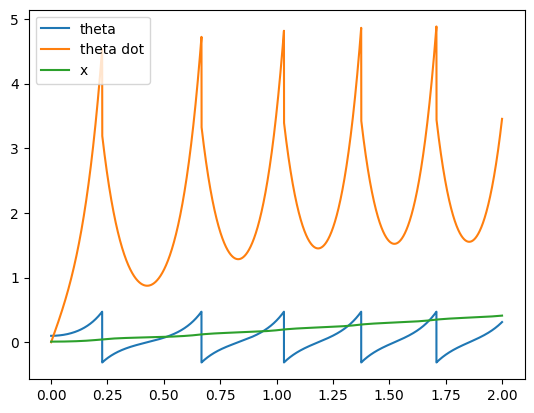

In [33]:
Tsim, Xsim, Usim, Xcentersim= rimlessWheel.simulate(
              t0=0.0,
              x0=[0.1, 0.0],
              tf=2.0,
              dt=0.0001,
              integrator="euler")
plot_timeseries_RW(Tsim, Xsim, U=None, x_cent = Xcentersim)

The only variable in the previous plot which is not affected by the reset is the position of the center of mass, which we calculate using the contact point. 

## Think-Pair-Share (10 min)

We can also visualize the results as an animation. Try playing around with different numbers of spokes, slopes and leg lengths (you will need to instantiate the RimlessWheelPlant each time). 
- Does the simulation converge to the same state each time? 
- What are the possible outcomes of this simulation?
- What determines the long-term behavior of the system?
- Since we are going downhill, why do we not accelerate indefinitely?

In [34]:
%%capture
Tsim, Xsim, Usim, anim, Xcenter = rimlessWheel.simulate_and_animate(
              t0=0.0,
              x0=[0.1, 5.0],
              tf=5.0,
              dt=0.001,
              controller=None,
              integrator="runge_kutta")

In [35]:
HTML(anim.to_html5_video())


KeyboardInterrupt



Run the cell below to make the system appear in Meshcat.

In [36]:
# Start visualizer
scene = Scene(wait_for_open=False)
display(IFrame(scene.vis.url(), width="100%", height=200))
cam_pos = np.array([100, 0, 5])

scene.camera_pos = cam_pos
scene.camera_zoom = 8
floor = Object.create_cuboid(lengths = [1.0, 30.0, 0.1], name='floor', color=[0.8, 0.8, 0.8])
r = Robot(urdf_path='rimless_wheel.urdf')
scene.add_object(floor)
scene.add_robot(r)
floor_l = 30
floor_z = 5.0
scene['floor'].rot = rotate('x', -gamma)
scene['floor'].pos = [0.0, 0.0, floor_z-2.0]
x0 = [0.0, 0.0, floor_z]
r.pos = x0

You can open the visualizer by visiting the following URL:
https://cloudpendulum.m2.chalmers.se:1443/user/sahand_wag/proxy/7052/static/


And we provide a helper function to change the systems

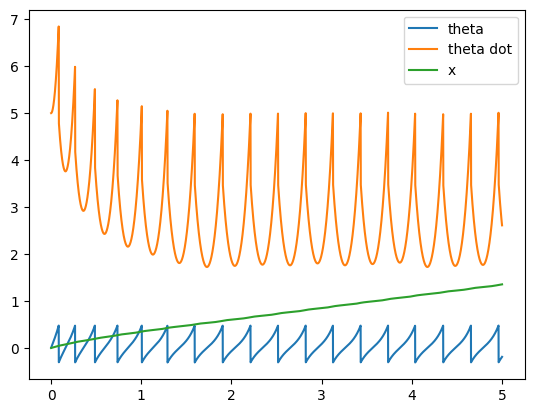

In [37]:
def rimless_wheel(slope=0.08, initial_angle=0.0, initial_angular_velocity=5.0):
    dt = 0.001
    rimlessWheel.gamma = slope
    x0 = [initial_angle, initial_angular_velocity]
    Tsim, Xsim, Usim, Xcenter = rimlessWheel.simulate(
              t0=0.0,
              x0=x0,
              tf=5.0,
              dt=dt,
              controller=None,
              integrator="runge_kutta")
    # Plot
    plot_timeseries_RW(Tsim, Xsim, U=None, x_cent = Xcenter)
    # Set the initial conditions for the animation
    scene['floor'].rot = rotate('x', -slope)
    x0 = [0.0, -floor_l*0.4, floor_z - 0.5 + floor_l*0.4*np.sin(gamma)]
    r.pos = x0
    r.rot = rotate('x', initial_angle)
    # Start the animation
    frame = 0
    xcenter = x0[1]
    while frame < int(5.0 / (dt*2)) - 2:
        frame += 2
        
        # Assuming you're updating the center of the wheel based on position or velocity
        # If you're moving along a path defined by some angle or velocity:
        
        # Assuming r.pos[0] and r.pos[2] are x and z positions (or whatever the plane is)
        r.pos[1] += Xsim[frame][1] * 2*dt * math.cos(Xsim[frame][0]) # Update x-position with velocity and angle
        r.pos[2] -= Xsim[frame][1] * 2*dt * math.sin(Xsim[frame][0])  # Update z-position similarly (for a 3D path)
    
        # Update rotation based on angle
        r.rot = rotate('x', -Xsim[frame][0])

        time.sleep(dt*2)
rimless_wheel()

You can run the cell below to update the animation. Try changing the slope and initial configuration of your system. In what ways does the response of the system change? In what ways does it stay the same?

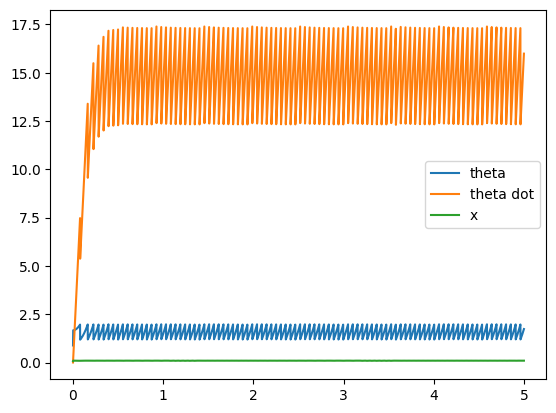

In [41]:
rimless_wheel(slope=np.pi*0.5,initial_angular_velocity=-0.1, initial_angle=0.1)

# 3. Compass Gait

The compass walker is a more complex model than the rimless wheel. It is a system with more degrees of freedom and less points of contact than the rimless wheel. In this model, since both legs are the same in length, we assume that the swinging leg will only collide with the ground when it has already gone past the stance leg.

<div style="display: flex; justify-content: space-around;">
    <div><img src="media/compass.png" width="400"></div>
</div>

This system is a bit more complex than the rimless wheel, so we will be defining most equations symbolically. To avoid integrating with constraints, we can use the minimal coordinates. However, we will later see that we need more extensive coordinates for calculating the reset map.
### Dynamics (minimal coordinates)
First, define the necessary symbolic variables.

In [42]:
# Declare symbols
t = sym.Symbol('t')
m, m_h, a, b, g = sym.symbols('m m_h a b g')
l = a + b
x, y, th_st, th_sw = sym.symbols('x y theta_st theta_sw', cls=sym.Function)

# Generalized coordinates and derivatives
th_st = th_st(t)
th_sw = th_sw(t)
x = x(t)
y = y(t)

q = sym.Matrix([th_st, th_sw])
dq = q.diff(t)
ddq = dq.diff(t)

Since the system consists of fairly few degrees of freedom, Euler-Lagrange as introduced in the previous lectures and tutorial can be used to quickly obtain the equations of motion.

In [43]:
from helper_funs import obtain_matrix_form_EL
r_stance_mass = sym.Matrix([
    -a*sym.sin(th_st),
     a*sym.cos(th_st)
])
r_h_mass = sym.Matrix([
    -l*sym.sin(th_st),
     l*sym.cos(th_st)
])
r_swing_mass = sym.Matrix([
    -l*sym.sin(th_st) - b*sym.sin(th_sw),
     l*sym.cos(th_st) - b*sym.cos(th_sw)
])

# Velocities
v_stance_mass = r_stance_mass.diff(t)
v_h_mass = r_h_mass.diff(t)
v_swing_mass = r_swing_mass.diff(t)

# Kinetic energy
K = (0.5*v_stance_mass.T*m*v_stance_mass + 0.5*v_h_mass.T*m_h*v_h_mass + 0.5*v_swing_mass.T*m*v_swing_mass)[0]

# Potential energy
V = m*g*r_stance_mass[1] + m_h*g*r_h_mass[1] + m*g*r_swing_mass[1]

# Obtain the M, C, G matrices
M, C, G = obtain_matrix_form_EL(K, V, q, dq, t)

print('Mass matrix')
display(M)
print('Coriolis/centrifugal matrix')
display(C)
print('Gravitational matrix')
display(G)

Mass matrix


Matrix([
[2.0*a**2*m + 1.0*a**2*m_h + 2.0*a*b*m + 2.0*a*b*m_h + 1.0*b**2*m + 1.0*b**2*m_h, 1.0*b*m*(a + b)*cos(theta_st(t) + theta_sw(t))],
[                                 1.0*b*m*(a + b)*cos(theta_st(t) + theta_sw(t)),                                     1.0*b**2*m]])

Coriolis/centrifugal matrix


Matrix([
[                                                                            -1.0*b*m*(a + b)*sin(theta_st(t) + theta_sw(t))*Derivative(theta_sw(t), t), -1.0*b*m*(a + b)*sin(theta_st(t) + theta_sw(t))*Derivative(theta_st(t), t) - 1.0*b*m*(a + b)*sin(theta_st(t) + theta_sw(t))*Derivative(theta_sw(t), t)],
[-1.0*b*m*(a + b)*sin(theta_st(t) + theta_sw(t))*Derivative(theta_st(t), t) - 1.0*b*m*(a + b)*sin(theta_st(t) + theta_sw(t))*Derivative(theta_sw(t), t),                                                                             -1.0*b*m*(a + b)*sin(theta_st(t) + theta_sw(t))*Derivative(theta_st(t), t)]])

Gravitational matrix


Matrix([
[g*(-a*m - m*(a + b) - m_h*(a + b))*sin(theta_st(t))],
[                             b*g*m*sin(theta_sw(t))]])

As you can see, the matrices are quite extensive. To avoid retyping them, we can convert the sympy functions directly into numpy functions.

In [44]:
from sympy import lambdify
# Convert into usable numpy functions
dx, dy, dth_st, dth_sw = sym.symbols('dx dy dtheta_st dtheta_sw')
q_sym = q
dq_sym = sym.Matrix([dth_st, dth_sw])
sub_list = [(x.diff(t), dx), (y.diff(t), dy), (th_st.diff(t), dth_st), (th_sw.diff(t), dth_sw)]
Q  = sym.IndexedBase('q')
dQ  = sym.IndexedBase('dq')
subs_X = {}
for i, var in enumerate(q):
    subs_X[var] = Q[i]
for i, var in enumerate(dq_sym):
    subs_X[var] = dQ[i]
# Create the proper functions
Mf = lambdify((Q, m, m_h, a, b, g), M.subs(sub_list).subs(subs_X), "numpy")
Cf = lambdify((Q, dQ, m, m_h, a, b, g), C.subs(sub_list).subs(subs_X), "numpy")
Gf = lambdify((Q, m, m_h, a, b, g), G.subs(sub_list).subs(subs_X), "numpy")

The benefit of obtaining the block matrix form directly, is that the forward dynamics can be described using the general equations of motion:
$$\ddot{q} = -M^{-1}(q)(C(q, \dot{q})\dot{q} + G(q))$$

In [45]:
def forward_dynamics(self, q, dq):
    th_st, th_sw = q
    th_st_dot, th_sw_dot = dq
    M_val = self.M(q, self.m, self.m_h, self.a, self.b, self.g)
    C_val = self.C(q, dq, self.m, self.m_h, self.a, self.b, self.g)
    G_val = self.G(q, self.m, self.m_h, self.a, self.b, self.g)

    # Compute accelerations (ddq)
    dq_col = np.array([th_st_dot, th_sw_dot]).reshape((2, 1))
    ddq = np.linalg.inv(M_val)@(-G_val - C_val @ dq_col) ## TYPE HERE!!
    return ddq.flatten()

def f(self, t, x):
    q = x[:2]
    dq = x[2:]
    # Compute accelerations using forward dynamics
    ddq = self.forward_dynamics(np.array(q), np.array(dq))
    xdot = np.concatenate([dq, ddq])
    
    return xdot

def step(self, dt, integrator='euler'):
    # Integrate forward using the selected integrator
    if integrator == "runge_kutta":
        self.x = self.runge_integrator(self.t, self.x, dt)
    elif integrator == "euler":
        self.x = self.euler_integrator(self.t, self.x, dt)

    # Update time
    self.t += dt

    # Store the time series output
    self.t_values.append(self.t)
    self.x_values.append(self.x.copy())
    self.contact_values.append(self.contactpoint.copy())
    th_st, th_sw, th_st_dot, th_sw_dot = self.x

    return self.x

Now let's test how the compass walker behaves during a single phase!

In [46]:
%%capture
from compasswalker_plant import *
hip_mass = 10.0  # mass at hip  [kg]
mass = 5.0      # mass at legs
a_val = 0.5         # length from leg mass to foot [m]
b_val = 0.5         # length from hip to leg mass [m]
gamma = 0.0525   # inclination [rad]
gravity = 9.81  # gravity [kg m/s^2]
params = [mass, hip_mass, a, b, g, gamma]
compassWalker = CompassWalkerPlant(hip_mass=hip_mass,
                                   mass=mass,
                                   a=a_val,
                                   b=b_val,
                                   gamma = gamma,
                                   gravity=gravity,
                                    matrices = [Mf, Cf, Gf])
CompassWalkerPlant.forward_dynamics = forward_dynamics
CompassWalkerPlant.f = f
CompassWalkerPlant.step = step
x0 = [0.1, -0.4, 0.5, 0.0]
Tsim, Xsim = compassWalker.simulate(
          t0=0.0,
          x0=x0,
          tf=1.0,
          dt=0.01,
          controller=None,
          integrator="runge_kutta")

anim = compassWalker.animate_from_data(Tsim, Xsim, dt = 0.01, fps = 30, skip = 5)

In [47]:
HTML(anim.to_html5_video())

Right now, the compass walker falls through the ground, so we need to implement the contact conditions and reset map.
## Think-Pair-Share (5 min)

- What logic would you use to detect collisions in the compass walker model?
- How many different distinct phases and reset maps does this system have?

## Contact detection
A good place to start is by finding the position of the swing foot.

In [48]:
def get_swing_foot_pos(self):
    # Extract current angles and contact point
    th_st, th_sw = self.x[:2]
    x, y = self.contactpoint

    # Compute swing toe position
    sw_foot_pos = np.array([
            x + self.l * np.sin(th_st) - self.l * np.sin(th_sw), ## TYPE HERE!
            y + self.l * np.cos(th_st) - self.l * np.cos(th_sw)
        ])
                              
    return sw_foot_pos

def get_swing_foot_vel(self):
    th_st, th_sw = self.x[:2]
    th_st_dot, th_sw_dot = self.x[2:4]  # assuming velocities are stored here

    vx = self.l * np.cos(th_st) * th_st_dot - self.l * np.cos(th_sw) * th_sw_dot
    vy = -self.l * np.sin(th_st) * th_st_dot + self.l * np.sin(th_sw) * th_sw_dot

    return np.array([vx, vy])

CompassWalkerPlant.get_swing_foot_pos = get_swing_foot_pos
CompassWalkerPlant.get_swing_foot_vel = get_swing_foot_vel

Using the swing foot position, we can then check for contact with the ground. For this, we need to find the height of the slope at the swing foot position.

**NOTE: We also need to ensure that $\dot{e}(x)<0$. Think about why this is the case.**

In [49]:
def contact_detection(self):
    # Swing toe position
    sw_foot_x, sw_foot_y = self.get_swing_foot_pos()
    sw_foot_vel = self.get_swing_foot_vel()

    # Current stance foot (contact point)
    stance_x, stance_y = self.contactpoint
    
    # Extract angular velocities
    th_st, th_sw = self.x[:2]
    th_st_dot, th_sw_dot = self.x[2:]
    
    # Expected slope height under the toe
    ground_y = stance_y - (sw_foot_x - stance_x) * np.tan(self.gamma) ## Type here!!
    # Swing foot velocity
    J_sw = np.array([
        [self.l * np.cos(th_st), -self.l * np.cos(th_sw)],  # x derivatives
        [-self.l * np.sin(th_st), self.l * np.sin(th_sw)]   # y derivatives
    ])
    #sw_foot_vel = J_sw@self.x[2:]
    eps = 1e-5
    slope_normal = np.array([-np.sin(self.gamma),np.cos(self.gamma)])
    height = sw_foot_y - ground_y
    normal_vel = slope_normal @ sw_foot_vel
    # Trigger only when approaching from above
    if not self.in_contact and height <= eps and normal_vel < -eps and abs(th_st - th_sw)>1e-1 and sw_foot_x>stance_x:
        self.in_contact = True
        return True, np.array([sw_foot_x, ground_y])

    # Reset when clearly above ground again
    if height > 20 * eps:
        self.in_contact = False
    
    return False, None

CompassWalkerPlant.contact_detection = contact_detection

Now, all that's left is to calculate the reset map. As the swing foot hits comes to a stop immediately, energy is lost during impact.
## Think-Pair-Share (5 min)
For the rimless wheel, the reset map was 
$$
L(t^{-}) = -m l^2 \dot{\theta}(t^{-}) \cos(2\alpha)
$$
For the compass walker, the expression is:
\begin{equation*}
    \dot{\mathbf q}^+ = \left[ \mathbf I -
      \mathbf M_\text{fb}^{-1}\mathbf J^T[\mathbf J\mathbf M_\text{fb}^{-1}\mathbf J^T]^{-1}\mathbf J\right] \dot{\mathbf q}^-.
\end{equation*}
Where $M_{fb}$ denotes the mass matrix including the pre-impact swing foot position $x, y$, and $J$ denotes the jacobian of the swing toe position $\phi(q)$.
- How do the two impact maps relate? What are the differences and similarities?

Now, let us implement the impact map. For this, we require the block matrices including the swing foot position. However, we need to calculate the full mass matrix and swing toe positions in terms of the swing foot coordinates to avoid overconstraining.

In [50]:
# Free body coordinates
qfull = sym.Matrix([x, y, th_st, th_sw])
dqfull = sym.Matrix([x.diff(t), y.diff(t), th_st.diff(t), th_sw.diff(t)])
# Calculate the positions
r_stance_mass = sym.Matrix([
    x - a*sym.sin(th_st),
    y + a*sym.cos(th_st)
])
r_h_mass = sym.Matrix([
    x - l*sym.sin(th_st),
    y + l*sym.cos(th_st)
])
r_swing_mass = sym.Matrix([
    x - l*sym.sin(th_st) - b*sym.sin(th_sw),
    y + l*sym.cos(th_st) - b*sym.cos(th_sw)
])

# Velocities
v_stance_mass = r_stance_mass.diff(t)
v_h_mass = r_h_mass.diff(t)
v_swing_mass = r_swing_mass.diff(t)

# Kinetic energy
K = (0.5*v_stance_mass.T*m*v_stance_mass + 0.5*v_h_mass.T*m_h*v_h_mass + 0.5*v_swing_mass.T*m*v_swing_mass)[0]

# Potential energy
V = m*g*r_stance_mass[1] + m_h*g*r_h_mass[1] + m*g*r_swing_mass[1]

# Obtain the M, C, G matrices
M, C, G = obtain_matrix_form_EL(K, V, qfull, dqfull, t)
# Kinetic energy
K = (0.5*v_stance_mass.T*m*v_stance_mass + 0.5*v_h_mass.T*m_h*v_h_mass + 0.5*v_swing_mass.T*m*v_swing_mass)[0]

# Potential energy
V = m*g*r_stance_mass[1] + m_h*g*r_h_mass[1] + m*g*r_swing_mass[1]

# Obtain the M, C, G matrices
M_full, C, G = obtain_matrix_form_EL(K, V, q, dq, t)
# Convert M in a usable function
dx, dy, dth_st, dth_sw = sym.symbols('dx dy dtheta_st dtheta_sw')
X = sym.Matrix([x, y, th_st, th_sw])
dX = sym.Matrix([dx, dy, dth_st, dth_sw])
sub_list = [(x.diff(t), dx), (y.diff(t), dy), (th_st.diff(t), dth_st), (th_sw.diff(t), dth_sw)]
Q  = sym.IndexedBase('q')
dQ  = sym.IndexedBase('dq')
subs_X = {}
for i, var in enumerate(X):
    subs_X[var] = Q[i]
for i, var in enumerate(dX):
    subs_X[var] = dQ[i]
# Create the proper functions
M_fullf = lambdify((Q, m, m_h, a, b, g), M.subs(sub_list).subs(subs_X), "numpy")

r_swing_foot = sym.Matrix([x + l * sym.sin(th_st) - l * sym.sin(th_sw),
            y + l * sym.cos(th_st) - l * sym.cos(th_sw)
])
J_foot = r_swing_foot.jacobian(X)
J_footf = lambdify((Q, m, m_h, a, b, g), J_foot.subs(sub_list).subs(subs_X), "numpy")
display(J_foot)
display(M)

Matrix([
[1, 0,  (a + b)*cos(theta_st(t)), -(a + b)*cos(theta_sw(t))],
[0, 1, -(a + b)*sin(theta_st(t)),  (a + b)*sin(theta_sw(t))]])

Matrix([
[                                      2.0*m + 1.0*m_h,                                                     0,                           -1.0*(a*m + m*(a + b) + m_h*(a + b))*cos(theta_st(t)),                      -1.0*b*m*cos(theta_sw(t))],
[                                                    0,                                       2.0*m + 1.0*m_h,                           -1.0*(a*m + m*(a + b) + m_h*(a + b))*sin(theta_st(t)),                       1.0*b*m*sin(theta_sw(t))],
[-1.0*(a*m + m*(a + b) + m_h*(a + b))*cos(theta_st(t)), -1.0*(a*m + m*(a + b) + m_h*(a + b))*sin(theta_st(t)), 2.0*a**2*m + 1.0*a**2*m_h + 2.0*a*b*m + 2.0*a*b*m_h + 1.0*b**2*m + 1.0*b**2*m_h, 1.0*b*m*(a + b)*cos(theta_st(t) + theta_sw(t))],
[                            -1.0*b*m*cos(theta_sw(t)),                              1.0*b*m*sin(theta_sw(t)),                                  1.0*b*m*(a + b)*cos(theta_st(t) + theta_sw(t)),                                     1.0*b**2*m]])

As you can see, the Mass matrix becomes a lot more extensive.

Using these functions, define the reset map:

In [51]:
def reset_map(self, qmin, dqmin):
    # Swap the coordinates around
    qplus = [qmin[1], qmin[0]]
    # Compute the post-impact velocity
    xmin, ymin = self.contactpoint# + np.array([-self.l*np.sin(qmin[1])+self.l*np.sin(qmin[0]), self.l*np.cos(qmin[1])-self.l*np.cos(qmin[0])])
    Xmin = np.array([xmin, ymin, qmin[0], qmin[1]])
    # the necessary matrices
    J_val = J_footf(Xmin, self.m, self.m_h, self.a, self.b, self.g)
    M_val = M_fullf(Xmin, self.m, self.m_h, self.a, self.b, self.g)
    M_inv = np.linalg.inv(M_val)
    I = np.eye(4)

    dX_min = np.array([0.0, 0.0, dqmin[0], dqmin[1]]).reshape(4, 1) # Recall that the velocities are zero of the foot
    dqplus = (I - M_inv@J_val.T@np.linalg.inv(J_val@M_inv@J_val.T)@J_val)@dX_min

    #
    xplus = xmin + self.l * np.sin(qplus[1]) - self.l * np.sin(qplus[0])
    yplus = ymin - self.l * np.cos(qplus[0]) + self.l * np.cos(qplus[1])
    self.contactpoint = np.array([xplus, yplus])
    return qplus, dqplus[2:].flatten()

CompassWalkerPlant.reset_map = reset_map

The last thing we should do is include the contact in the step of the simulator. For this, we simply update the step function defined before.

In [52]:
def step(self, dt, integrator='euler'):
    # Check for contact
    contact, contact_point = self.contact_detection()
    if contact == True:
        qmin, dqmin = self.x[:2], self.x[2:]
        qplus, dqplus = self.reset_map(qmin, dqmin)
        self.x = np.concatenate([qplus, dqplus])
        self.contactpoint = contact_point
        print('COLLISION', self.t)
    # Integrate forward using the selected integrator
    if integrator == "runge_kutta":
        self.x = self.runge_integrator(self.t, self.x, dt)
    elif integrator == "euler":
        self.x = self.euler_integrator(self.t, self.x, dt)

    # Update time
    self.t += dt

    # Store the time series output
    self.t_values.append(self.t)
    self.x_values.append(self.x.copy())
    self.contact_values.append(self.contactpoint.copy())
    
    th_st, th_sw, th_st_dot, th_sw_dot = self.x

    return self.x

CompassWalkerPlant.step = step

Let's simulate and see what happens.

In [55]:
%%capture
x0 = [0, 0.1, 0.4, -2.0]
compassWalker.m_h = 10
compassWalker.gamma = 0.032
Tsim, Xsim = compassWalker.simulate(
          t0=0.0,
          x0=x0,
          tf=5.0,
          dt=0.001,
          controller=None,
          integrator="runge_kutta")

anim = compassWalker.animate_from_data(Tsim, Xsim, dt = 0.001, fps = 30, skip = 100)

In [56]:
HTML(anim.to_html5_video())

Try and play around with different initial conditions, including the slope. Can you find any stable gaits?